
|78/*# DS Day 01 — Agriculture: Why Is Crop Yield Different?

This notebook performs the complete analysis requested in the challenge:

- Data cleaning and validation
- Exploratory data analysis and descriptive statistics
- 4 visualizations
- Comparison of regions and crop varieties
- Fertiliser usage vs crop yield analysis
- Irrigation vs crop yield analysis
- Identification of potentially inefficient farming practices
- Random Forest prediction model
- Model evaluation
- Feature importance
- 5–7 key insights and a practical action plan

**Expected input file:** `DS_Day01_32_Agriculture_Crop_Yield_Dataset.csv`


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')


## 1. Load the dataset

### Uploading the agriculture dataset

If you encounter a `FileNotFoundError`, upload the CSV file using the file upload icon on the left sidebar in Google Colab, or drag and drop it into the Colab file explorer.


In [29]:
import os

file_path = 'DS_Day01_32_Agriculture_Crop_Yield_Dataset.csv'

if os.path.exists(file_path):
    print(f'The file {file_path} exists in the current directory.')
else:
    print(f'The file {file_path} does NOT exist in the current directory. Please upload it as instructed above.')


The file DS_Day01_32_Agriculture_Crop_Yield_Dataset.csv exists in the current directory.


In [30]:
# Change this filename if your CSV has a different name.
df = pd.read_csv(os.path.join('/content', file_path))

print('Shape:', df.shape)
display(df.head())

Shape: (1005, 9)


,Farm_ID,Region,Crop_Type,Rainfall,Soil_Properties,Irrigation,Fertiliser_Use,Temperature,Crop_Yield
0,F0001,West,Sugarcane,992.49,87.85,Low,124.77,31.04,89.22
1,F0002,Central,Maize,734.46,65.33,Medium,100.03,26.00,88.88
2,F0003,East,Wheat,844.62,70.33,High,96.62,34.65,56.04
3,F0004,South,Rice,1096.27,55.97,Low,179.83,24.87,87.23
4,F0005,North,Wheat,571.67,81.38,Medium,68.51,27.79,95.00


## 2. Clean and validate the data

In [31]:
required_cols = [
    'Farm_ID', 'Region', 'Crop_Type', 'Rainfall',
    'Soil_Properties', 'Irrigation', 'Fertiliser_Use',
    'Temperature', 'Crop_Yield'
]

missing_cols = [c for c in required_cols if c not in df.columns]
print('Missing required columns:', missing_cols)

print('\nData types:')
display(df.dtypes)

print('\nMissing values:')
display(df.isnull().sum())

print('\nDuplicate rows:', df.duplicated().sum())

# Remove exact duplicate rows
df = df.drop_duplicates().copy()

# Convert numerical columns
numeric_cols = [
    'Rainfall',
    'Soil_Properties',
    'Fertiliser_Use',
    'Temperature',
    'Crop_Yield'
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Clean categorical columns
categorical_cols = ['Region', 'Crop_Type', 'Irrigation']

for col in categorical_cols:
    df[col] = df[col].astype('string').str.strip()

# Fill missing numerical values with median
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill missing categorical values with mode
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print('\nMissing values after cleaning:')
display(df.isnull().sum())

print('\nCleaned shape:', df.shape)


Missing required columns: []

Data types:


,0
Farm_ID,object
Region,object
Crop_Type,object
Rainfall,float64
Soil_Properties,float64
Irrigation,object
Fertiliser_Use,float64
Temperature,float64
Crop_Yield,float64



Missing values:


,0
Farm_ID,0
Region,0
Crop_Type,2
Rainfall,4
Soil_Properties,0
Irrigation,2
Fertiliser_Use,3
Temperature,2
Crop_Yield,0



Duplicate rows: 5

Missing values after cleaning:


,0
Farm_ID,0
Region,0
Crop_Type,0
Rainfall,0
Soil_Properties,0
Irrigation,0
Fertiliser_Use,0
Temperature,0
Crop_Yield,0



Cleaned shape: (1000, 9)


## 3. Descriptive statistics

These statistics help identify the typical rainfall, soil condition, fertiliser use, temperature and crop yield.


In [32]:
display(df[numeric_cols].describe().round(2))

print('Region distribution:')
display(df['Region'].value_counts(dropna=False))

print('Crop type distribution:')
display(df['Crop_Type'].value_counts(dropna=False))

print('Irrigation distribution:')
display(df['Irrigation'].value_counts(dropna=False))


,Rainfall,Soil_Properties,Fertiliser_Use,Temperature,Crop_Yield
count,1000.00,1000.00,1000.00,1000.00,1000.00
mean,853.02,65.64,115.34,26.99,83.92
std,221.50,14.45,34.28,4.15,11.44
min,300.00,25.00,30.00,17.00,36.32
25%,706.35,55.92,94.18,24.08,77.26
50%,851.25,66.14,115.97,27.09,84.02
75%,1013.40,75.39,139.42,29.75,91.69
max,1494.00,100.00,220.00,38.00,116.96


Region distribution:


,count
Region,
Central,234
East,213
West,205
North,176
South,172


Crop type distribution:


,count
Crop_Type,
Rice,279
Wheat,202
Maize,198
Sugarcane,177
Cotton,144


Irrigation distribution:


,count
Irrigation,
Medium,428
Low,317
High,255


## 4. Average crop yield by region and crop variety

In [33]:
region_avg = (
    df.groupby('Region')['Crop_Yield']
      .agg(['mean', 'median', 'count'])
      .sort_values('mean', ascending=False)
)

crop_avg = (
    df.groupby('Crop_Type')['Crop_Yield']
      .agg(['mean', 'median', 'count'])
      .sort_values('mean', ascending=False)
)

print('Region-wise crop yield:')
display(region_avg.round(2))

print('Crop-wise crop yield:')
display(crop_avg.round(2))


Region-wise crop yield:


,mean,median,count
Region,,,
South,87.11,87.12,172
Central,84.03,84.15,234
West,83.72,84.93,205
North,82.65,83.50,176
East,82.46,82.66,213


Crop-wise crop yield:


,mean,median,count
Crop_Type,,,
Sugarcane,88.65,88.89,177
Rice,85.70,85.54,279
Maize,84.33,85.00,198
Wheat,80.44,81.58,202
Cotton,78.96,80.03,144


## 5. Visualization 1 — Crop type vs average crop yield

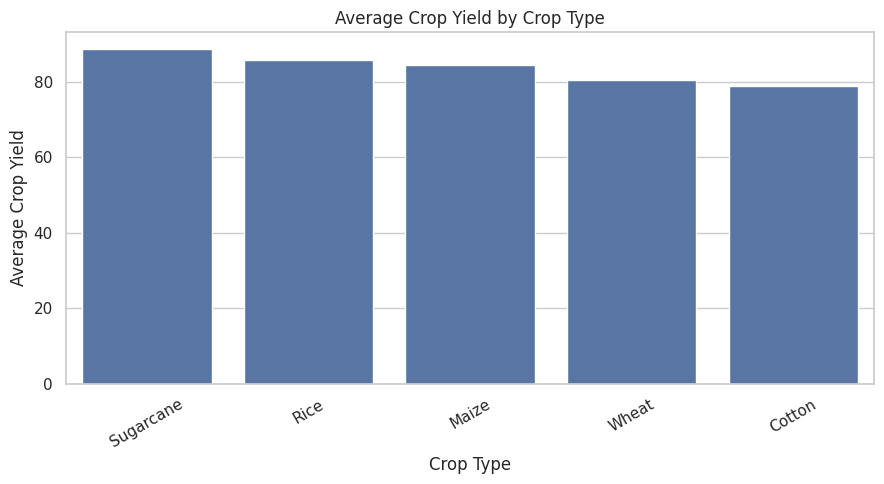

In [34]:
crop_plot = (
    df.groupby('Crop_Type', as_index=False)['Crop_Yield']
      .mean()
      .sort_values('Crop_Yield', ascending=False)
)

plt.figure(figsize=(9, 5))
sns.barplot(data=crop_plot, x='Crop_Type', y='Crop_Yield')
plt.title('Average Crop Yield by Crop Type')
plt.xlabel('Crop Type')
plt.ylabel('Average Crop Yield')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


## 6. Visualization 2 — Region vs average crop yield

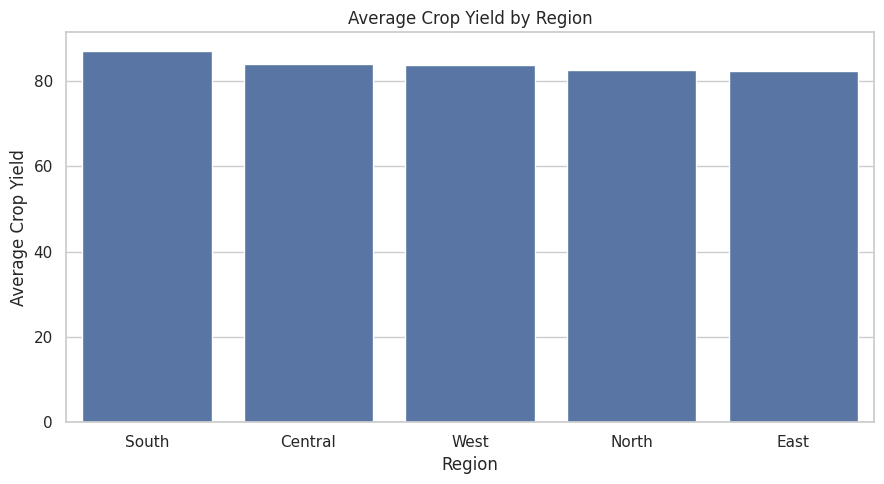

In [35]:
region_plot = (
    df.groupby('Region', as_index=False)['Crop_Yield']
      .mean()
      .sort_values('Crop_Yield', ascending=False)
)

plt.figure(figsize=(9, 5))
sns.barplot(data=region_plot, x='Region', y='Crop_Yield')
plt.title('Average Crop Yield by Region')
plt.xlabel('Region')
plt.ylabel('Average Crop Yield')
plt.tight_layout()
plt.show()


## 7. Visualization 3 — Fertiliser use vs crop yield

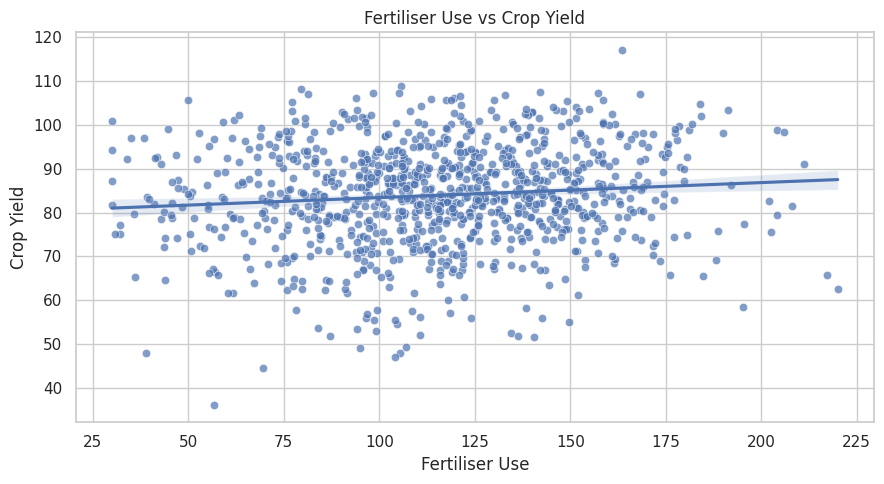

Correlation between Fertiliser Use and Crop Yield: 0.102


In [36]:
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df, x='Fertiliser_Use', y='Crop_Yield', alpha=0.7)
sns.regplot(
    data=df,
    x='Fertiliser_Use',
    y='Crop_Yield',
    scatter=False
)
plt.title('Fertiliser Use vs Crop Yield')
plt.xlabel('Fertiliser Use')
plt.ylabel('Crop Yield')
plt.tight_layout()
plt.show()

fertiliser_corr = df['Fertiliser_Use'].corr(df['Crop_Yield'])
print('Correlation between Fertiliser Use and Crop Yield:',
      round(fertiliser_corr, 3))


## 8. Visualization 4 — Irrigation vs crop yield

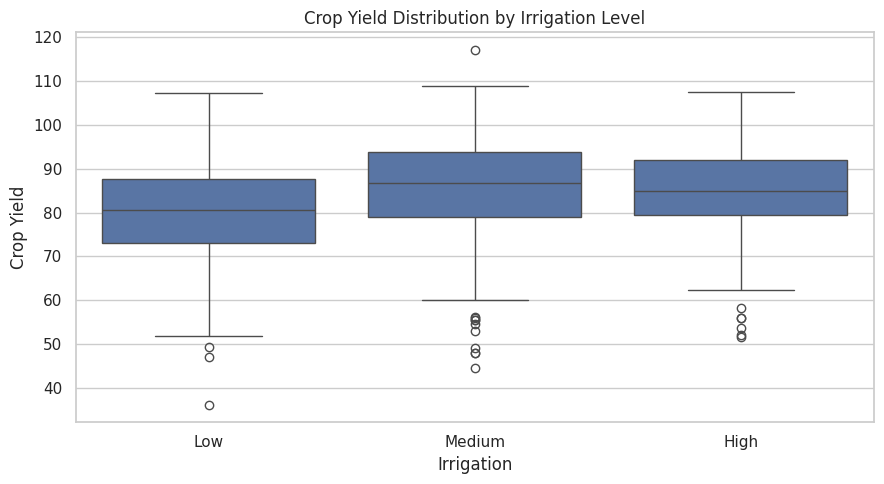

In [14]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x='Irrigation', y='Crop_Yield')
plt.title('Crop Yield Distribution by Irrigation Level')
plt.xlabel('Irrigation')
plt.ylabel('Crop Yield')
plt.tight_layout()
plt.show()


## 9. Analyse fertiliser usage against yield

Correlation is a first diagnostic, not proof of causation. We compare fertiliser usage with crop yield and also inspect fertiliser use by crop type.


In [15]:
fertiliser_by_crop = (
    df.groupby('Crop_Type')
      .agg(
          Avg_Fertiliser=('Fertiliser_Use', 'mean'),
          Avg_Yield=('Crop_Yield', 'mean'),
          Farms=('Farm_ID', 'count')
      )
      .sort_values('Avg_Yield', ascending=False)
)

display(fertiliser_by_crop.round(2))

print('Overall Fertiliser-Yield correlation:',
      round(fertiliser_corr, 3))


,Avg_Fertiliser,Avg_Yield,Farms
Crop_Type,,,
Sugarcane,113.12,88.65,177
Rice,116.02,85.70,279
Maize,115.65,84.33,198
Wheat,114.38,80.44,202
Cotton,117.66,78.96,144


Overall Fertiliser-Yield correlation: 0.102


## 10. Investigate whether additional irrigation always improves yield

We compare average yield across irrigation levels and then combine irrigation with rainfall level. This avoids assuming that more irrigation is automatically better.


In [16]:
irrigation_summary = (
    df.groupby('Irrigation')['Crop_Yield']
      .agg(['mean', 'median', 'min', 'max', 'count'])
      .sort_values('mean', ascending=False)
)

display(irrigation_summary.round(2))

df['Rainfall_Level'] = pd.qcut(
    df['Rainfall'],
    q=3,
    labels=['Low Rainfall', 'Medium Rainfall', 'High Rainfall'],
    duplicates='drop'
)

irrigation_rainfall = pd.pivot_table(
    df,
    values='Crop_Yield',
    index='Rainfall_Level',
    columns='Irrigation',
    aggfunc='mean'
)

print('Average yield by rainfall level and irrigation:')
display(irrigation_rainfall.round(2))


,mean,median,min,max,count
Irrigation,,,,,
Medium,85.81,86.62,44.72,116.96,428
High,85.52,84.91,51.78,107.41,255
Low,80.08,80.67,36.32,107.29,317


Average yield by rainfall level and irrigation:


/tmp/ipykernel_1724/4457034.py:16: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  irrigation_rainfall = pd.pivot_table(


Irrigation,High,Low,Medium
Rainfall_Level,,,
Low Rainfall,84.54,80.03,86.52
Medium Rainfall,86.72,79.33,86.55
High Rainfall,85.31,80.76,84.25


## 11. Identify potentially inefficient farming practices

A potentially inefficient practice is flagged when resource use is relatively high but crop yield is relatively low. This is an analytical flag for investigation, not proof of poor farming.


In [17]:
fertiliser_high = df['Fertiliser_Use'].quantile(0.75)
yield_low = df['Crop_Yield'].quantile(0.25)

inefficient_fertiliser = df[
    (df['Fertiliser_Use'] >= fertiliser_high) &
    (df['Crop_Yield'] <= yield_low)
].copy()

print('Potentially inefficient high-fertiliser / low-yield records:')
display(inefficient_fertiliser.head(15))
print('Number of flagged records:', len(inefficient_fertiliser))


Potentially inefficient high-fertiliser / low-yield records:


,Farm_ID,Region,Crop_Type,Rainfall,Soil_Properties,Irrigation,Fertiliser_Use,Temperature,Crop_Yield,Rainfall_Level
29,F0030,North,Rice,973.37,71.75,Low,177.26,20.79,74.44,High Rainfall
37,F0038,Central,Wheat,389.37,88.15,Low,161.31,32.77,68.60,Low Rainfall
42,F0043,West,Wheat,861.16,72.42,Medium,180.46,33.75,74.98,Medium Rainfall
45,F0046,West,Maize,822.60,52.73,Low,188.23,31.82,69.16,Medium Rainfall
71,F0072,North,Wheat,808.13,68.39,Low,144.39,18.68,63.46,Medium Rainfall
84,F0085,Central,Maize,1161.14,57.90,Low,161.57,35.00,69.38,High Rainfall
97,F0098,South,Sugarcane,1041.40,57.16,Low,151.72,32.26,71.34,High Rainfall
99,F0100,East,Sugarcane,635.28,59.96,Low,162.11,28.23,74.31,Low Rainfall
113,F0114,North,Cotton,1155.49,25.29,High,140.53,22.62,51.78,High Rainfall
162,F0163,East,Maize,1089.73,88.01,Medium,149.36,25.70,76.27,High Rainfall


Number of flagged records: 51


## 12. Numerical relationship analysis

In [18]:
corr_cols = [
    'Rainfall',
    'Soil_Properties',
    'Fertiliser_Use',
    'Temperature',
    'Crop_Yield'
]

corr = df[corr_cols].corr().round(3)

display(corr)

print('Absolute correlation with Crop_Yield:')
corr_target = (
    corr['Crop_Yield']
    .drop('Crop_Yield')
    .abs()
    .sort_values(ascending=False)
)

display(corr_target)


,Rainfall,Soil_Properties,Fertiliser_Use,Temperature,Crop_Yield
Rainfall,1.000,0.001,0.014,0.055,-0.012
Soil_Properties,0.001,1.000,0.048,-0.004,0.310
Fertiliser_Use,0.014,0.048,1.000,0.030,0.102
Temperature,0.055,-0.004,0.030,1.000,-0.006
Crop_Yield,-0.012,0.310,0.102,-0.006,1.000


Absolute correlation with Crop_Yield:


,Crop_Yield
Soil_Properties,0.310
Fertiliser_Use,0.102
Rainfall,0.012
Temperature,0.006


## 13. Correlation heatmap

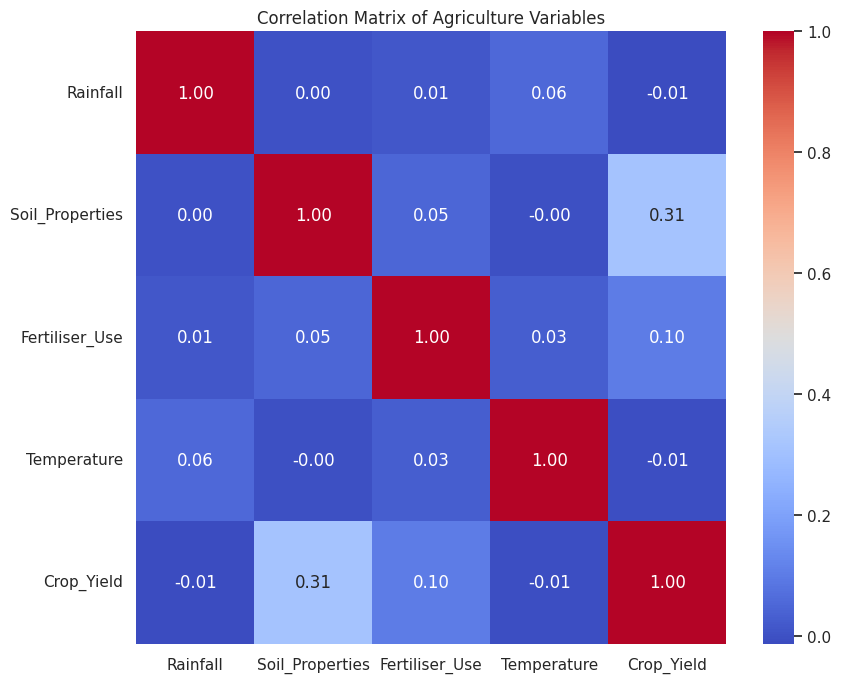

In [19]:
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Agriculture Variables')
plt.tight_layout()
plt.show()


## 14. Identify operational / farming problem areas

The tables below identify regions, crop types and irrigation groups with lower-than-overall average yield.


In [20]:
overall_yield = df['Crop_Yield'].mean()

region_problems = (
    df.groupby('Region')
      .agg(
          Avg_Crop_Yield=('Crop_Yield', 'mean'),
          Avg_Rainfall=('Rainfall', 'mean'),
          Avg_Soil=('Soil_Properties', 'mean'),
          Avg_Fertiliser=('Fertiliser_Use', 'mean'),
          Farms=('Farm_ID', 'count')
      )
      .sort_values('Avg_Crop_Yield')
)

region_problems['Below_Overall_Average'] = (
    region_problems['Avg_Crop_Yield'] < overall_yield
)

display(region_problems.round(2))

crop_problems = (
    df.groupby('Crop_Type')
      .agg(
          Avg_Crop_Yield=('Crop_Yield', 'mean'),
          Avg_Rainfall=('Rainfall', 'mean'),
          Avg_Fertiliser=('Fertiliser_Use', 'mean'),
          Farms=('Farm_ID', 'count')
      )
      .sort_values('Avg_Crop_Yield')
)

display(crop_problems.round(2))


,Avg_Crop_Yield,Avg_Rainfall,Avg_Soil,Avg_Fertiliser,Farms,Below_Overall_Average
Region,,,,,,
East,82.46,867.68,65.43,115.08,213,True
North,82.65,861.62,64.92,114.99,176,True
West,83.72,856.56,66.29,115.73,205,True
Central,84.03,817.37,65.80,116.43,234,False
South,87.11,870.36,65.64,114.06,172,False


,Avg_Crop_Yield,Avg_Rainfall,Avg_Fertiliser,Farms
Crop_Type,,,,
Cotton,78.96,861.72,117.66,144
Wheat,80.44,844.29,114.38,202
Maize,84.33,851.86,115.65,198
Rice,85.70,858.45,116.02,279
Sugarcane,88.65,848.65,113.12,177


## 15. Random Forest model

The prediction target is `Crop_Yield`. Numeric and categorical variables are handled through a preprocessing pipeline.


In [21]:
feature_cols = [
    'Region',
    'Crop_Type',
    'Rainfall',
    'Soil_Properties',
    'Irrigation',
    'Fertiliser_Use',
    'Temperature'
]

model_df = df[feature_cols + ['Crop_Yield']].dropna().copy()

X = model_df[feature_cols]
y = model_df['Crop_Yield']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

categorical_features = [
    'Region',
    'Crop_Type',
    'Irrigation'
]

numeric_features = [
    'Rainfall',
    'Soil_Properties',
    'Fertiliser_Use',
    'Temperature'
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            'categorical',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_features
        ),
        (
            'numeric',
            'passthrough',
            numeric_features
        )
    ]
)

rf_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', RandomForestRegressor(
            n_estimators=250,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

rf_pipeline.fit(X_train, y_train)

print('Random Forest model trained successfully.')
print('Training records:', len(X_train))
print('Testing records:', len(X_test))


Random Forest model trained successfully.
Training records: 800
Testing records: 200


## 16. Make predictions

In [22]:
pred = rf_pipeline.predict(X_test)

prediction_results = pd.DataFrame({
    'Actual_Crop_Yield': y_test.values,
    'Predicted_Crop_Yield': pred
})

display(prediction_results.head(10).round(2))


,Actual_Crop_Yield,Predicted_Crop_Yield
0,79.76,90.30
1,86.54,84.22
2,99.51,84.69
3,71.64,82.14
4,88.45,83.59
5,55.63,57.28
6,89.20,91.98
7,85.88,90.61
8,73.13,67.68
9,53.04,63.16


## 17. Model evaluation

In [23]:
mae = mean_absolute_error(y_test, pred)
mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, pred)

print(f'MAE  : {mae:.2f}')
print(f'MSE  : {mse:.2f}')
print(f'RMSE : {rmse:.2f}')
print(f'R²   : {r2:.3f}')

evaluation = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R2'],
    'Value': [mae, mse, rmse, r2]
})

display(evaluation.round(3))


MAE  : 6.48
MSE  : 63.57
RMSE : 7.97
R²   : 0.510


,Metric,Value
0,MAE,6.477
1,MSE,63.571
2,RMSE,7.973
3,R2,0.510


## 18. Actual vs predicted crop yield

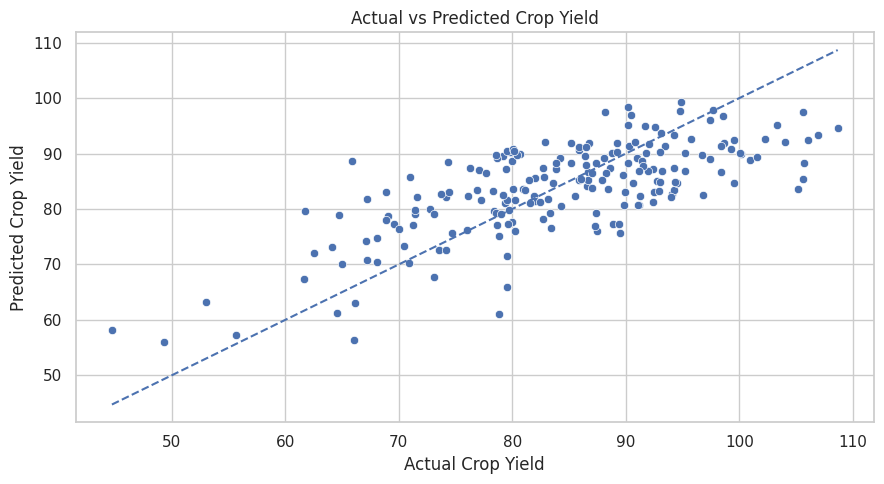

In [24]:
plt.figure(figsize=(9, 5))
sns.scatterplot(x=y_test, y=pred)

min_value = min(y_test.min(), pred.min())
max_value = max(y_test.max(), pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle='--'
)

plt.xlabel('Actual Crop Yield')
plt.ylabel('Predicted Crop Yield')
plt.title('Actual vs Predicted Crop Yield')
plt.tight_layout()
plt.show()


## 19. Feature importance

This shows which model inputs contribute most to the Random Forest predictions. For one-hot encoded categorical variables, multiple encoded columns may represent the same original feature.


In [25]:
feature_names = rf_pipeline.named_steps['preprocessor'].get_feature_names_out()
importances = rf_pipeline.named_steps['model'].feature_importances_

feature_importance = (
    pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    })
    .sort_values('Importance', ascending=False)
)

display(feature_importance.head(15).round(4))


,Feature,Importance
16,numeric__Temperature,0.4305
14,numeric__Soil_Properties,0.1968
15,numeric__Fertiliser_Use,0.1083
13,numeric__Rainfall,0.0895
11,categorical__Irrigation_Low,0.0400
5,categorical__Crop_Type_Cotton,0.0204
3,categorical__Region_South,0.0161
8,categorical__Crop_Type_Sugarcane,0.0158
9,categorical__Crop_Type_Wheat,0.0157
1,categorical__Region_East,0.0108


## 20. Feature importance visualization

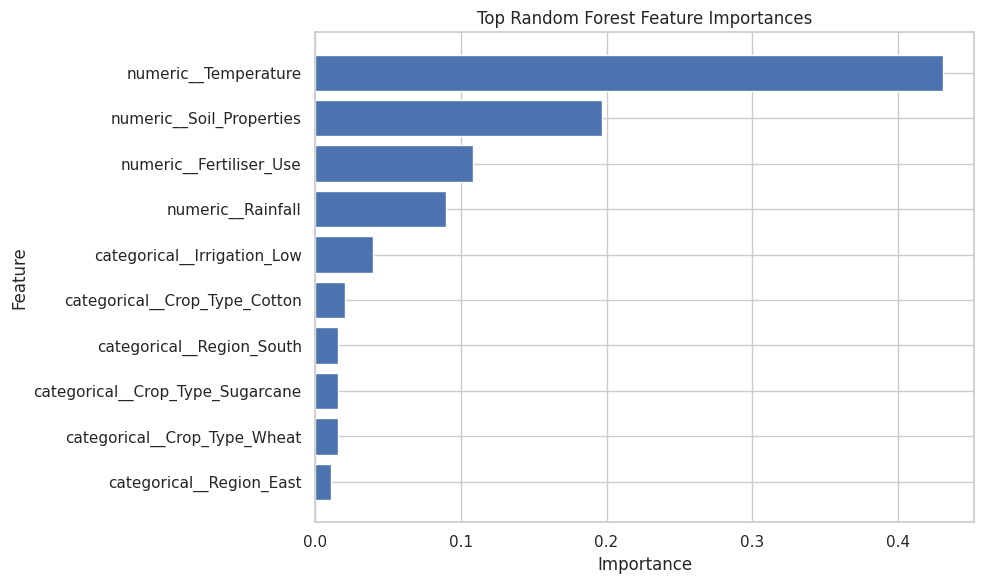

In [26]:
top_features = feature_importance.head(10).sort_values('Importance')

plt.figure(figsize=(10, 6))
plt.barh(
    top_features['Feature'],
    top_features['Importance']
)
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top Random Forest Feature Importances')
plt.tight_layout()
plt.show()


## 21. Automatically generate key findings

Run this section after the model and analysis cells. It prints data-driven statements that can be used in the final report.


In [27]:
top_region = region_avg.index[0]
top_region_yield = region_avg.iloc[0]['mean']

low_region = region_avg.index[-1]
low_region_yield = region_avg.iloc[-1]['mean']

top_crop = crop_avg.index[0]
top_crop_yield = crop_avg.iloc[0]['mean']

low_crop = crop_avg.index[-1]
low_crop_yield = crop_avg.iloc[-1]['mean']

top_irrigation = irrigation_summary.index[0]
top_irrigation_yield = irrigation_summary.iloc[0]['mean']

print('KEY INSIGHTS')
print('-' * 70)

print(f'1. Overall average crop yield: {df["Crop_Yield"].mean():.2f}')
print(f'2. Region with highest average yield: {top_region} ({top_region_yield:.2f})')
print(f'3. Region with lowest average yield: {low_region} ({low_region_yield:.2f})')
print(f'4. Crop type with highest average yield: {top_crop} ({top_crop_yield:.2f})')
print(f'5. Crop type with lowest average yield: {low_crop} ({low_crop_yield:.2f})')
print(f'6. Fertiliser-Yield correlation: {fertiliser_corr:.3f}')
print(f'7. Irrigation category with highest average yield: {top_irrigation} ({top_irrigation_yield:.2f})')
print(f'8. Random Forest R² score: {r2:.3f}')


KEY INSIGHTS
----------------------------------------------------------------------
1. Overall average crop yield: 83.92
2. Region with highest average yield: South (87.11)
3. Region with lowest average yield: East (82.46)
4. Crop type with highest average yield: Sugarcane (88.65)
5. Crop type with lowest average yield: Cotton (78.96)
6. Fertiliser-Yield correlation: 0.102
7. Irrigation category with highest average yield: Medium (85.81)
8. Random Forest R² score: 0.510


## 22. Practical action plan

Use the actual results printed above to support the recommendations.

1. **Fertiliser management:** avoid simply increasing fertiliser; compare usage with soil properties, crop type and observed yield.
2. **Irrigation management:** do not assume that additional irrigation always improves yield. Consider rainfall and crop requirements.
3. **Region-specific planning:** investigate lower-yield regions using rainfall, soil, temperature and resource-use patterns.
4. **Crop selection:** compare crop varieties using historical yield and environmental conditions before choosing a crop.
5. **Efficiency monitoring:** investigate farms with high fertiliser use but low yield.
6. **Predictive farming:** use the Random Forest model and feature importance to identify important predictive variables.
7. **Continuous monitoring:** collect future-season data and validate whether these relationships remain consistent.


## Final submission checklist

- [x] Data cleaning and validation
- [x] Descriptive statistics
- [x] 4 visualizations
- [x] Region comparison
- [x] Crop variety comparison
- [x] Fertiliser usage vs yield analysis
- [x] Irrigation vs yield analysis
- [x] Inefficient farming practice identification
- [x] Random Forest model
- [x] MAE, MSE, RMSE and R² evaluation
- [x] Feature importance
- [x] 5–7+ data-driven insights
- [x] Practical action plan

**Note:** The numerical findings will be generated after the CSV dataset is loaded. Use the results from the actual dataset in your final report.
